# **Figure-2-Referen-Based-Library-Construction**

In [1]:
import pandas as pd
import polars as pl
from functools import reduce
from itertools import combinations
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict
import sys
import numpy as np
import matplotlib as mpl

from matplotlib.patches import FancyArrowPatch
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker


sys.path.append("../../scripts")

from figure_utils import *

In [2]:
print("Pandas Version", pd.__version__)
print("Polars Version", pl.__version__)
print("numpy Version", np.__version__)
print("matplotlib version", mpl.__version__)
print("seaborn version", sns.__version__)
print("Python Version", sys.version)

Pandas Version 2.2.3
Polars Version 1.28.1
numpy Version 2.2.2
matplotlib version 3.10.0
seaborn version 0.13.2
Python Version 3.12.4 (main, Jun  7 2024, 23:47:47) [GCC 13.3.0]


In [3]:
names = dict(exp='Experimental',
             silico='in-silico',
             bruker='timsTOF, 2024',
             panhuman='PanHuman, 2014',
             diatracer='Direct')

condition = dict(orig='Initial', refined='GPF-based')

## **Load Data**

#### **OSW - Identification Rates**

In [4]:
osw = { n:defaultdict(dict) for n in names.values() }

# Diatracer data
osw[names['diatracer']][condition['orig']]['1'] = getPrecursorSet("../../results/K562-diaTracer/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet")
osw[names['diatracer']][condition['orig']]['2'] = getPrecursorSet("../../results/K562-diaTracer/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet")
osw[names['diatracer']][condition['orig']]['3'] = getPrecursorSet("../../results/K562-diaTracer/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet")

osw[names['diatracer']][condition['refined']]['1'] = getPrecursorSet("../../results/K562-GPF-diaTracer-OSW-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet")
osw[names['diatracer']][condition['refined']]['2'] = getPrecursorSet("../../results/K562-GPF-diaTracer-OSW-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet")
osw[names['diatracer']][condition['refined']]['3'] = getPrecursorSet("../../results/K562-GPF-diaTracer-OSW-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet")

# Bruker data
osw[names['bruker']][condition['orig']]['1'] = getPrecursorSet("../../results/K562-Bruker-Library-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet")
osw[names['bruker']][condition['orig']]['2'] = getPrecursorSet("../../results/K562-Bruker-Library-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet")
osw[names['bruker']][condition['orig']]['3'] = getPrecursorSet("../../results/K562-Bruker-Library-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet")

osw[names['bruker']][condition['refined']]['1'] = getPrecursorSet("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet")
osw[names['bruker']][condition['refined']]['2'] = getPrecursorSet("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet")
osw[names['bruker']][condition['refined']]['3'] = getPrecursorSet("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet")

# Panhuman data - Use SVM because XGBoost overfits 
osw[names['panhuman']][condition['orig']]['1'] = getPrecursorSet_oswpq("../../results/K562-PanHuman-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq/")
osw[names['panhuman']][condition['orig']]['2'] = getPrecursorSet_oswpq("../../results/K562-PanHuman-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.oswpq/")
osw[names['panhuman']][condition['orig']]['3'] = getPrecursorSet_oswpq("../../results/K562-PanHuman-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.oswpq/")

osw[names['panhuman']][condition['refined']]['1'] = getPrecursorSet_oswpq("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq/")
osw[names['panhuman']][condition['refined']]['2'] = getPrecursorSet_oswpq("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.oswpq/")
osw[names['panhuman']][condition['refined']]['3'] = getPrecursorSet_oswpq("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.oswpq/")

# Experimental data
osw[names['exp']][condition['orig']]['1'] = getPrecursorSet("../../results/K562-Exp-Lib-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet")
osw[names['exp']][condition['orig']]['2'] = getPrecursorSet("../../results/K562-Exp-Lib-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet")
osw[names['exp']][condition['orig']]['3'] = getPrecursorSet("../../results/K562-Exp-Lib-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet")

osw[names['exp']][condition['refined']]['1'] = getPrecursorSet("../../results/K562-Exp-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet")
osw[names['exp']][condition['refined']]['2'] = getPrecursorSet("../../results/K562-Exp-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet")
osw[names['exp']][condition['refined']]['3'] = getPrecursorSet("../../results/K562-Exp-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet")

# Silico data
osw[names['silico']][condition['orig']]['1'] = getPrecursorSet_oswpq("../../results/K562-PeptDeep-NoMods-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq")
osw[names['silico']][condition['orig']]['2'] = getPrecursorSet_oswpq("../../results/K562-PeptDeep-NoMods-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.oswpq")
osw[names['silico']][condition['orig']]['3'] = getPrecursorSet_oswpq("../../results/K562-PeptDeep-NoMods-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.oswpq")

osw[names['silico']][condition['refined']]['1'] = getPrecursorSet("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet")
osw[names['silico']][condition['refined']]['2'] = getPrecursorSet("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet")
osw[names['silico']][condition['refined']]['3'] = getPrecursorSet("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet")

../../results/K562-diaTracer/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet
../../results/K562-diaTracer/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet
../../results/K562-diaTracer/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet
../../results/K562-GPF-diaTracer-OSW-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet
../../results/K562-GPF-diaTracer-OSW-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet
../../results/K562-GP

#### **DIA-NN Identification Rates**

In [5]:
diann = { n:defaultdict(dict) for n in names.values() }


# Bruker data
diann[names['bruker']][condition['orig']]['1'] = getPrecursorSetDiann("../../results/K562-Bruker-Library-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann[names['bruker']][condition['orig']]['2'] = getPrecursorSetDiann("../../results/K562-Bruker-Library-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv")
diann[names['bruker']][condition['orig']]['3'] = getPrecursorSetDiann("../../results/K562-Bruker-Library-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv")

diann[names['bruker']][condition['refined']]['1'] = getPrecursorSetDiann("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann[names['bruker']][condition['refined']]['2'] = getPrecursorSetDiann("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv")
diann[names['bruker']][condition['refined']]['3'] = getPrecursorSetDiann("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv")

# Silico data
diann[names['silico']][condition['orig']]['1'] = getPrecursorSetDiann("../../results/K562-PeptDeep-NoMods-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann[names['silico']][condition['orig']]['2'] = getPrecursorSetDiann("../../results/K562-PeptDeep-NoMods-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv")
diann[names['silico']][condition['orig']]['3'] = getPrecursorSetDiann("../../results/K562-PeptDeep-NoMods-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv")

diann[names['silico']][condition['refined']]['1'] = getPrecursorSetDiann("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann[names['silico']][condition['refined']]['2'] = getPrecursorSetDiann("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv")
diann[names['silico']][condition['refined']]['3'] = getPrecursorSetDiann("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv")

# Diatracer data
diann[names['diatracer']][condition['orig']]['1'] = getPrecursorSetDiann("../../results/K562-diaTracer/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann[names['diatracer']][condition['orig']]['2'] = getPrecursorSetDiann("../../results/K562-diaTracer/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv")
diann[names['diatracer']][condition['orig']]['3'] = getPrecursorSetDiann("../../results/K562-diaTracer/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv")

diann[names['diatracer']][condition['refined']]['1'] = getPrecursorSetDiann("../../results/K562-GPF-diaTracer-DIANN-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann[names['diatracer']][condition['refined']]['2'] = getPrecursorSetDiann("../../results/K562-GPF-diaTracer-DIANN-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv")
diann[names['diatracer']][condition['refined']]['3'] = getPrecursorSetDiann("../../results/K562-GPF-diaTracer-DIANN-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv")

# exp data
diann[names['exp']][condition['orig']]['1'] = getPrecursorSetDiann("../../results/K562-Exp-Lib-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann[names['exp']][condition['orig']]['2'] = getPrecursorSetDiann("../../results/K562-Exp-Lib-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv")
diann[names['exp']][condition['orig']]['3'] = getPrecursorSetDiann("../../results/K562-Exp-Lib-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv")

diann[names['exp']][condition['refined']]['1'] = getPrecursorSetDiann("../../results/K562-Exp-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv", infer_schema_length=1000)
diann[names['exp']][condition['refined']]['2'] = getPrecursorSetDiann("../../results/K562-Exp-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv", infer_schema_length=1000)
diann[names['exp']][condition['refined']]['3'] = getPrecursorSetDiann("../../results/K562-Exp-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv", infer_schema_length=1000)

# Panhuman data
diann[names['panhuman']][condition['orig']]['1'] = getPrecursorSetDiann("../../results/K562-PanHuman-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann[names['panhuman']][condition['orig']]['2'] = getPrecursorSetDiann("../../results/K562-PanHuman-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv")
diann[names['panhuman']][condition['orig']]['3'] = getPrecursorSetDiann("../../results/K562-PanHuman-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv")

diann[names['panhuman']][condition['refined']]['1'] = getPrecursorSetDiann("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann[names['panhuman']][condition['refined']]['2'] = getPrecursorSetDiann("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv")
diann[names['panhuman']][condition['refined']]['3'] = getPrecursorSetDiann("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv")

../../results/K562-Bruker-Library-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv
../../results/K562-Bruker-Library-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv
../../results/K562-Bruker-Library-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv
../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv
../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv
../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv
../../results/K562-PeptDeep-NoMods-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv
../../results/K562-PeptDeep-NoMods-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_10

In [6]:
osw_ids = format_ids_vs_reproducibility(osw)
diann_ids = format_ids_vs_reproducibility(diann)

#### **OSW Quantification Curves**

In [7]:
osw_quant = { n:defaultdict(dict) for n in names.values() }

# Diatracer data
osw_quant[names['diatracer']][condition['orig']]['1'] = getPrecursorDf("../../results/K562-diaTracer/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet", 1)
osw_quant[names['diatracer']][condition['orig']]['2'] = getPrecursorDf("../../results/K562-diaTracer/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet", 2)
osw_quant[names['diatracer']][condition['orig']]['3'] = getPrecursorDf("../../results/K562-diaTracer/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet", 3)

osw_quant[names['diatracer']][condition['refined']]['1'] = getPrecursorDf("../../results/K562-GPF-diaTracer-OSW-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet", 1)
osw_quant[names['diatracer']][condition['refined']]['2'] = getPrecursorDf("../../results/K562-GPF-diaTracer-OSW-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet", 2)
osw_quant[names['diatracer']][condition['refined']]['3'] = getPrecursorDf("../../results/K562-GPF-diaTracer-OSW-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet", 3)

# Bruker data
osw_quant[names['bruker']][condition['orig']]['1'] = getPrecursorDf("../../results/K562-Bruker-Library-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet", 1)
osw_quant[names['bruker']][condition['orig']]['2'] = getPrecursorDf("../../results/K562-Bruker-Library-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet", 2)
osw_quant[names['bruker']][condition['orig']]['3'] = getPrecursorDf("../../results/K562-Bruker-Library-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet", 3)

osw_quant[names['bruker']][condition['refined']]['1'] = getPrecursorDf("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet", 1)
osw_quant[names['bruker']][condition['refined']]['2'] = getPrecursorDf("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet", 2)
osw_quant[names['bruker']][condition['refined']]['3'] = getPrecursorDf("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet", 3)

# Panhuman data - Use SVM because XGBoost overfits 
osw_quant[names['panhuman']][condition['orig']]['1'] = getPrecursorDf_oswpq("../../results/K562-PanHuman-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq/", 1)
osw_quant[names['panhuman']][condition['orig']]['2'] = getPrecursorDf_oswpq("../../results/K562-PanHuman-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.oswpq/", 2)
osw_quant[names['panhuman']][condition['orig']]['3'] = getPrecursorDf_oswpq("../../results/K562-PanHuman-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.oswpq/", 3)

osw_quant[names['panhuman']][condition['refined']]['1'] = getPrecursorDf_oswpq("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq/", 1)
osw_quant[names['panhuman']][condition['refined']]['2'] = getPrecursorDf_oswpq("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.oswpq/", 2)
osw_quant[names['panhuman']][condition['refined']]['3'] = getPrecursorDf_oswpq("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.oswpq/", 3)

# Experimental data
osw_quant[names['exp']][condition['orig']]['1'] = getPrecursorDf("../../results/K562-Exp-Lib-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet", 1)
osw_quant[names['exp']][condition['orig']]['2'] = getPrecursorDf("../../results/K562-Exp-Lib-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet", 2)
osw_quant[names['exp']][condition['orig']]['3'] = getPrecursorDf("../../results/K562-Exp-Lib-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet", 3)

osw_quant[names['exp']][condition['refined']]['1'] = getPrecursorDf("../../results/K562-Exp-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet", 1)
osw_quant[names['exp']][condition['refined']]['2'] = getPrecursorDf("../../results/K562-Exp-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet", 2)
osw_quant[names['exp']][condition['refined']]['3'] = getPrecursorDf("../../results/K562-Exp-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet", 3)

# Silico data
osw_quant[names['silico']][condition['orig']]['1'] = getPrecursorDf_oswpq("../../results/K562-PeptDeep-NoMods-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq", 1)
osw_quant[names['silico']][condition['orig']]['2'] = getPrecursorDf_oswpq("../../results/K562-PeptDeep-NoMods-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.oswpq", 2)
osw_quant[names['silico']][condition['orig']]['3'] = getPrecursorDf_oswpq("../../results/K562-PeptDeep-NoMods-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.oswpq", 3)

osw_quant[names['silico']][condition['refined']]['1'] = getPrecursorDf("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet", 1)
osw_quant[names['silico']][condition['refined']]['2'] = getPrecursorDf("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet", 2)
osw_quant[names['silico']][condition['refined']]['3'] = getPrecursorDf("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet", 3)

../../results/K562-diaTracer/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet
../../results/K562-diaTracer/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet
../../results/K562-diaTracer/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet
../../results/K562-GPF-diaTracer-OSW-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet
../../results/K562-GPF-diaTracer-OSW-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet
../../results/K562-GP

In [8]:
cvs = defaultdict(dict)
for lib, v in osw_quant.items():
    for cond, vv in v.items():
        print(lib, cond)
        cvs[lib][cond] = computeCVs(vv)
        

cvs_df = []
for lib, v in cvs.items():
    tmp = []
    for cond, vv in v.items():
        vv['Condition'] = cond
        vv['Library'] = lib
        vv['Index'] = np.arange(1, len(vv) + 1)
        tmp.append(vv)
    cvs_df.append(pd.concat(tmp))

cvs_df = pd.concat(cvs_df)
cvs_df = cvs_df.reset_index()

Experimental Initial
Experimental GPF-based
in-silico Initial
in-silico GPF-based
timsTOF, 2024 Initial
timsTOF, 2024 GPF-based
PanHuman, 2014 Initial
PanHuman, 2014 GPF-based
Direct Initial
Direct GPF-based


#### **Load Example Precursor Characteristics**

In [9]:
prec = 'ENSIEILSSTIK'
chg = 2

gpf_full_feature = pd.read_parquet("../../results/K562-Refine-PeptDeep-NoMods-With-GPF/osw/pyprophet_XGB/merged.oswpqd/RostDIA640_SP2um_90min_250ngK562_100nL_Slot1-5_1_1320_6-27-2021.oswpq/precursors_features.parquet", columns=['MODIFIED_SEQUENCE', 'DELTA_RT', 'EXP_RT', 'PRECURSOR_CHARGE', 'SCORE_MS2_PEAK_GROUP_RANK', 'SCORE_MS2_PEP', 'LEFT_WIDTH', 'RIGHT_WIDTH'])
gpf_full_feature = gpf_full_feature[(gpf_full_feature['MODIFIED_SEQUENCE'] == prec) & 
                                        (gpf_full_feature['PRECURSOR_CHARGE'] == chg) &
                                        (gpf_full_feature['SCORE_MS2_PEAK_GROUP_RANK'] == 1)].iloc[0]

reg_full_feature_orig = pd.read_parquet("../../results/K562-PeptDeep-NoMods-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq/precursors_features.parquet", columns=['MODIFIED_SEQUENCE', 'DELTA_RT', 'EXP_RT', 'PRECURSOR_CHARGE', 'SCORE_MS2_PEAK_GROUP_RANK', 'SCORE_MS2_PEP', 'LEFT_WIDTH', 'RIGHT_WIDTH'])
reg_full_feature_orig = reg_full_feature_orig[(reg_full_feature_orig['MODIFIED_SEQUENCE'] == prec) & 
                                        (reg_full_feature_orig['PRECURSOR_CHARGE'] == chg) &
                                        (reg_full_feature_orig['SCORE_MS2_PEAK_GROUP_RANK'] == 1)].iloc[0]

reg_full_feature = pd.read_parquet("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet", columns=['PEPTIDE.MODIFIED_SEQUENCE', 'FEATURE.DELTA_RT', 'FEATURE.EXP_RT', 'PRECURSOR.CHARGE', 'SCORE_MS2.RANK', 'SCORE_MS2.PEP', 'FEATURE.LEFT_WIDTH', 'FEATURE.RIGHT_WIDTH'])
reg_full_feature = reg_full_feature[(reg_full_feature['PEPTIDE.MODIFIED_SEQUENCE'] == prec) & 
                                        (reg_full_feature['PRECURSOR.CHARGE'] == chg) &
                                        (reg_full_feature['SCORE_MS2.RANK'] == 1)].iloc[0]

#### **Load Example Precursor Chromatograms**

In [10]:
reg_chromatograms_only_ms2 = pd.read_pickle("reg_chromatogram.pkl")
gpf_chromatograms_only_ms2 = pd.read_pickle("gpf_chromatogram.pkl")

## **Plot**

In [11]:
def createChromatograms(ax1, 
                        ax2, 
                        xlim=(4600, 5050), 
                        ylim=(0, 400), 
                        line_width=1.0,
                        vspan_color='yellow', 
                        vspan_alpha=0.3, 
                        vline_color = 'tab:blue',
                        vline_color2 = 'tab:orange',
                        text_y=320,
                        font_size_small=7,
                        font_size_medium=9,
                        font_size_large=11,
                        font_size_title=12,
                        labelpad=3):
    
    # --- Data Retrieval (Assuming these variables are available in the scope) ---
    target_sample_pep_orig_lib = reg_full_feature_orig['SCORE_MS2_PEP']
    target_sample_pep_refined_lib = reg_full_feature['SCORE_MS2.PEP']
    reference_sample_pep_orig_lib = gpf_full_feature['SCORE_MS2_PEP']
    
    # --- Plot Reference Sample (ax1) ---
    gpf_chromatograms_only_ms2[gpf_chromatograms_only_ms2['annotation'] != 'Precursor'].plot(
        backend='ms_matplotlib',
        x='rt',
        y='intensity',
        by='annotation',
        kind='chromatogram',
        title='Reference Sample (High Selectivity)',
        xlabel='',
        canvas=ax1,
        line_width=line_width,
        show_plot=False,
        title_font_size=font_size_large,
        xaxis_label_font_size=font_size_large,
        yaxis_label_font_size=font_size_large, 
        xaxis_labelpad=labelpad,
        yaxis_labelpad=labelpad,
        xaxis_tick_font_size=font_size_medium,
        yaxis_tick_font_size=font_size_medium,
        grid=False,
        legend_config=dict(show=True)
    )
    ax1.set_xlim(*xlim)
    ax1.set_ylim(*ylim)
    ax1.axvspan(gpf_full_feature['LEFT_WIDTH'] - 8, gpf_full_feature['RIGHT_WIDTH'], color=vspan_color, alpha=vspan_alpha)

    ax1.axvline(gpf_full_feature['EXP_RT'] - gpf_full_feature['DELTA_RT'], color=vline_color, lw=2, ls='--') # Reduced lw from 3 to 2
    ax1.text(
        gpf_full_feature['EXP_RT'] - gpf_full_feature['DELTA_RT'] - 10,
        text_y,
        'Initial RT',
        ha='right',
        fontsize=font_size_small,
        color='white',
        bbox=dict(
            facecolor=vline_color,
            edgecolor='black',
            boxstyle='round,pad=0.15'
        )
    )

    # --- Plot Target Sample (ax2) ---
    reg_chromatograms_only_ms2.plot(
        backend='ms_matplotlib',
        x='rt',
        y='intensity',
        by='annotation',
        kind='chromatogram',
        xlabel='Retention Time (RT)',
        title='Target Sample (Lower Selectivity)',
        canvas=ax2,
        line_width=line_width,
        show_plot=False,
        title_font_size=font_size_large,
        xaxis_label_font_size=font_size_large,
        yaxis_label_font_size=font_size_large, 
        xaxis_labelpad=labelpad,
        yaxis_labelpad=labelpad,
        xaxis_tick_font_size=font_size_medium,
        yaxis_tick_font_size=font_size_medium,
        grid=False,
        legend_config=dict(show=False)
    )
    ax2.set_xlim(*xlim)
    ax2.set_ylim(*ylim)
    ax2.axvspan(reg_full_feature['FEATURE.LEFT_WIDTH'], reg_full_feature['FEATURE.RIGHT_WIDTH'], color=vspan_color, alpha=vspan_alpha)
    ax2.axvline(reg_full_feature['FEATURE.EXP_RT'] - reg_full_feature['FEATURE.DELTA_RT'], color=vline_color2, lw=2, ls='--') # Reduced lw from 3 to 2

    ax2.text(
        reg_full_feature['FEATURE.EXP_RT'] - reg_full_feature['FEATURE.DELTA_RT'] - 15,
        text_y/2,
        'Reconstructed\nRT',
        ha='right',
        fontsize=font_size_small,
        color='black',
        bbox=dict(
            facecolor=vline_color2,
            edgecolor='black',
            boxstyle='round,pad=0.15'
        )
    )

    ax2.axvline(reg_full_feature['FEATURE.EXP_RT'] - reg_full_feature_orig['DELTA_RT'], color=vline_color, lw=2, ls='--') # Reduced lw from 3 to 2
    ax2.text(
        reg_full_feature['FEATURE.EXP_RT'] - reg_full_feature_orig['DELTA_RT'] - 10,
        text_y,
        'Initial RT',
        ha='right',
        fontsize=font_size_small,
        color='white',
        bbox=dict(
            facecolor=vline_color,
            edgecolor='black',
            boxstyle='round,pad=0.15'
        )
    )

    ax2.text(
        xlim[1] - 5,
        text_y,
        f'Initial PEP: {target_sample_pep_orig_lib:.2%}\nReconstructed PEP: {target_sample_pep_refined_lib:.2%}',
        ha='right',
        fontsize=font_size_small,
        color='black',
        bbox=dict(
            facecolor='white',
            edgecolor='black',
            boxstyle='round,pad=0.15'
        )
    )

    ax1.text(
        xlim[1] - 5,
        text_y+20,
        f'Initial PEP: {reference_sample_pep_orig_lib:.2%}',
        ha='right',
        fontsize=font_size_small, 
        color='black',
        bbox=dict(
            facecolor='white',
            edgecolor='black',
            boxstyle='round,pad=0.15'
        )
    )

    # --- Move legend to figure level ---
    handles, labels = ax1.get_legend().legend_handles, [t.get_text() for t in ax1.get_legend().get_texts()]
    
    # Assuming 'fig' is available in the global scope (common when calling plt.figure() before this function)
    fig = ax1.figure 

    ax2.legend(
        handles, labels,
        ncol=3,
        loc='lower center',
        bbox_to_anchor=(0.5,-0.9),
        fontsize=font_size_small
    )
    ax1.get_legend().remove()

    ax2.grid(axis='x')
    ax1.grid(axis='x')

    bbox = ax2.get_position()
    x_center = (bbox.x0 + bbox.x1) / 2

    ax2.text(
        (xlim[0] + xlim[1]) / 2,
        -450,
        f'{prec}/{chg}',
        ha='center',
        va='bottom',
        fontsize=font_size_large, 
        color='black',
        bbox=dict(facecolor='lightgrey', edgecolor='none', boxstyle='round,pad=0.15')
    )

In [12]:
def createID_Reproducibility_plot(df, 
                                  title, 
                                  ax, 
                                  show_legends=True, 
                                  panel_label='', 
                                  show_xlabel=True,
                                  show_ylabel=True,
                                  font_size_small = 7,
                                  font_size_medium = 9,
                                  font_size_large = 11,
                                  font_size_title = 11,
                                  xlabel='# Commonly Identified\nPeptide Precursors'):
    # Set style
    plt.style.use('default')
    sns.set_palette("husl")
    
    library_colors = {
        names['exp']: '#1f77b4',
        names['silico']: '#ff7f0e', 
        names['bruker']: '#2ca02c',
        names['panhuman']: '#d62728',
        names['diatracer']: '#9467bd'
    }
    
    point_size=30
    edge_width=1.5
    

    
    for library in df['Library'].unique():
        lib_data = df[df['Library'] == library]
        original = lib_data[lib_data['Condition'] == condition['orig']]
        refined = lib_data[lib_data['Condition'] == condition['refined']]
        color = library_colors[library]
        
        short_name = library.replace(' Library', '')
        ax.scatter(original['# IDs'], original['Jaccard Index'], 
                     s=point_size, facecolors='none', edgecolors=color, linewidth=edge_width, label=short_name)
        ax.scatter(refined['# IDs'], refined['Jaccard Index'],
                     s=point_size, c=color, alpha=0.9)
                     
        arrow = FancyArrowPatch(
            (original['# IDs'].iloc[0], original['Jaccard Index'].iloc[0]),
            (refined['# IDs'].iloc[0], refined['Jaccard Index'].iloc[0]),
            arrowstyle='->', mutation_scale=10, shrinkA=5, shrinkB=2,
            color=color, alpha=1, linewidth=1
        )
        ax.add_patch(arrow)
        
    if show_xlabel:
        ax.set_xlabel(xlabel, fontsize=font_size_medium)
    else:
        ax.set_xlabel('')
        
    if show_ylabel:
        ax.set_ylabel('                                                   Jaccard Index (Reproducibility)', fontsize=font_size_medium)
    
    x_min, x_max = df['# IDs'].min() - 2000, df['# IDs'].max() + 2000
    y_min, y_max = df['Jaccard Index'].min() - 0.01, df['Jaccard Index'].max() + 0.01
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
    ax.tick_params(axis='both', which='major', labelsize=font_size_small)
    ax.tick_params(axis='y', which='major', labelsize=font_size_small)
    
    ax.grid(True, alpha=0.3, linestyle='--')
    
    if panel_label:
        ax.text(0, 1.02, panel_label, transform=ax.transAxes, fontsize=font_size_large, 
                         fontweight='bold', verticalalignment='bottom', horizontalalignment='left')

    if show_legends:
        condition_legend_elements = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor='none', 
                   markeredgecolor='black', markersize=7, markeredgewidth=1.5, 
                   label=condition['orig'], linestyle='None'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='black', 
                   markersize=7, alpha=1, label=condition['refined'], linestyle='None'),
        ]
        library_legend_elements = []
        for library, color in library_colors.items():
            short_name = library.replace(' Library', '')
            library_legend_elements.append(
                Line2D([0], [0], marker='o', color='w', markerfacecolor=color,
                       markersize=5, alpha=1, label=short_name, 
                       linestyle='None')
            )
        legend1 = ax.legend(handles=condition_legend_elements, loc='lower center', bbox_to_anchor=(0.5, -1.2), 
                     fontsize=font_size_small)
        ax.add_artist(legend1)
        ax.legend(handles=library_legend_elements, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.9), 
                     fontsize=font_size_small)
    
    ax.set_xlim(50000, 145000)
    ax.set_ylim(0.69, 1.0)
    ax.set_title(title, fontsize=font_size_title)

In [13]:
def plot_cumulative_cv(ax, data, lib, xlabel=False, ylabel=False, font_size_small=7, font_size_medium=8, label_fontsize=9, title_fontsize=10, legend=False):
    # Define colors manually to match seaborn defaults
    colors = {condition['orig']: '#1f77b4', condition['refined']: '#ff7f0e'}  # seaborn default colors
    sns.set_palette(colors.values())
    g = sns.histplot(
        data=data[data['Library'] == lib],
        x="cv",
        hue="Condition",
        hue_order=condition.values(),
        stat='count', cumulative=True, element='step', fill=False, binrange=(0, 30), legend=False
    )

    ax.axvline(x=10, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(x=20, color='gray', linestyle='--', alpha=0.5)

    # Get data for this library
    lib_data = cvs_df[cvs_df['Library'] == lib]

    # Define colors manually to match seaborn defaults
    colors = {condition['orig']: '#1f77b4', condition['refined']: '#ff7f0e'}  # seaborn default colors

    # For each condition, find counts at 10% and 20% CV
    label_offset = {condition['orig']: -15, condition['refined']: 15}  # Different vertical offsets

    for i, condition_name in enumerate(condition.values()):
        cond_data = lib_data[lib_data['Condition'] == condition_name]

        # Count IDs with CV <= 10% and CV <= 20%
        count_10cv = len(cond_data[cond_data['cv'] <= 10])
        count_20cv = len(cond_data[cond_data['cv'] <= 20])

        color = colors.get(condition_name, ['#1f77b4', '#ff7f0e'][i])

        # Add points at 10% and 20% CV
        ax.plot(10, count_10cv, 'o', color=color, markersize=7, 
                markeredgecolor='white', markeredgewidth=1.5, zorder=10)
        ax.plot(20, count_20cv, 'o', color=color, markersize=7, 
                markeredgecolor='white', markeredgewidth=1.5, zorder=10)

        # Add labels with counts - positioned to avoid overlap
        offset_y = label_offset[condition_name]
        offset_x = -label_offset[condition_name] / 2

        ax.annotate(f'{count_10cv}', 
                    xy=(10, count_10cv), 
                    xytext=(offset_x, offset_y), 
                    textcoords='offset points',
                    fontsize=font_size_small, 
                    color=color,
                    fontweight='bold',
                    ha='center',
                    va='center',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', 
                               edgecolor=color, alpha=0.9, linewidth=1.5))

        ax.annotate(f'{count_20cv}', 
                       xy=(20, count_20cv), 
                       xytext=(0, offset_y), 
                       textcoords='offset points',
                       fontsize=font_size_small, 
                       color=color,
                       fontweight='bold',
                       ha='center',
                       va='center',
                       bbox=dict(boxstyle='round,pad=0.2', facecolor='white', 
                               edgecolor=color, alpha=0.9, linewidth=1.5))

    # Set better axis labels with larger fonts
    if xlabel:
        ax.set_xlabel("Coefficient of Variation", fontsize=label_fontsize)
    else:
        ax.set_xlabel("")
        
    if ylabel:
        ax.set_ylabel('# Peptide Precursors\n(Cumulative)', fontsize=label_fontsize)
    else:
        ax.set_ylabel("")
    
    ax.tick_params(axis='both', which='major', labelsize=font_size_small)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'{int(val / 1000)}K'))
    
    if legend:
        condition_legend_elements = [
            Line2D([0], [0], color='tab:blue',
                   label=condition['orig']),
            Line2D([0], [0], color='tab:orange', label=condition['refined']),
        ]
        ax.legend(handles=condition_legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.45), 
                     fontsize=font_size_small, ncol=2)        

    # Adjust titles for each subplot with larger fonts
    ax.set_title(lib, fontsize=title_fontsize)

#### **Alternative Figure**

Here plot the average number of identifications, note the shift in trends with DIA-NN. 

In [14]:
osw_ids = format_ids_vs_reproducibility(osw)
diann_ids = format_ids_vs_reproducibility(diann)

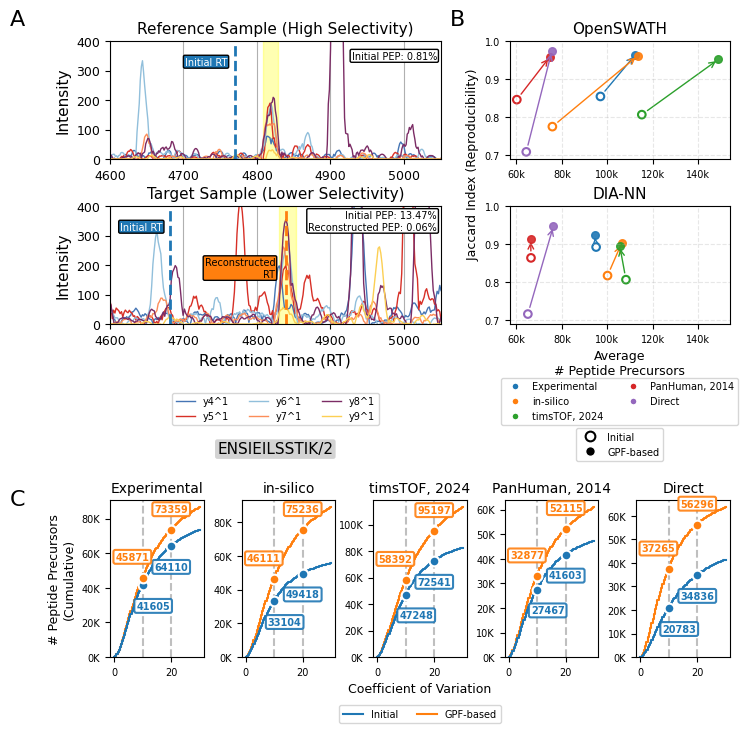

In [15]:
# We keep the 7x7 figure size
fig = plt.figure(figsize=(8, 8))

# Create main GridSpec: 2 rows, 1 column.
gs = gridspec.GridSpec(2, 1, height_ratios=[9, 5], hspace=0.8)

# --- Top Section: 2x2 grid with asymmetric widths ---
gs_top = gridspec.GridSpecFromSubplotSpec(
    2, 2, 
    subplot_spec=gs[0, 0], 
    hspace=0.4, 
    wspace=0.25,
    width_ratios=[3, 2] 
)

# Big plots
ax_big1 = fig.add_subplot(gs_top[0, 0])
ax_big2 = fig.add_subplot(gs_top[1, 0])
ax_big3 = fig.add_subplot(gs_top[0, 1])
ax_big4 = fig.add_subplot(gs_top[1, 1])


createChromatograms(ax_big1, ax_big2)
createID_Reproducibility_plot(osw_ids, title='OpenSWATH', ax=ax_big3, show_legends=False, panel_label='', show_xlabel=False, show_ylabel=False)
createID_Reproducibility_plot(diann_ids, title='DIA-NN', ax=ax_big4, show_legends=True, panel_label='', show_xlabel=True,  xlabel='Average\n# Peptide Precursors')
ax_big3.set_xlim(57000, 154000)
ax_big4.set_xlim(57000, 154000)

# --- Bottom Section: 1x5 grid for square Small plots ---
gs_bottom = gridspec.GridSpecFromSubplotSpec(
    1, 5, 
    subplot_spec=gs[1, 0], 
    wspace=0.4
)

# Quantification ID Curves
for i, lib in enumerate(names.values()):
    ax = fig.add_subplot(gs_bottom[0, i])
    kwargs = dict()
    if i==0:
        kwargs = dict(ylabel=True)
    elif i==2:
        kwargs = dict(xlabel=True, legend=True)
    plot_cumulative_cv(ax, cvs_df, lib, **kwargs)

fig.text(0, 0.9, 'A', fontsize=16) 
fig.text(0.55, 0.9, 'B', fontsize=16) 
fig.text(0, 0.3, 'C', fontsize=16) 
    
plt.savefig("figure2.png", dpi=300)

---

### **Numbers for Manuscript**

In [16]:
percent_increase(64348.333333, 75608.000000)

17.497992696612176

In [17]:
percent_increase(0.708823, 0.973730)

37.37279969752675

In [18]:
percent_increase(65056.000000, 76299.333333	)

17.282546318556324

In [19]:
percent_increase(0.716172, 0.947513)

32.30243572773021

### **CV Quant Curves Results**

In [20]:
percent_increase(34846, 56296)

61.55656316363428

In [21]:
percent_increase(34311, 64228)

87.1936113782752

In [22]:
percent_increase(75840.333333, 113390.666667)

49.512352707000716

In [23]:
percent_increase(0.775166, 0.961494)

24.037173973058664

In [24]:
percent_increase(100109.000000, 106269.333333)

6.153625880789941

In [25]:
percent_increase(0.82, 0.901868)

9.983902439024398

In [26]:
percent_increase(49418, 75236)

52.244121575134564

### **Effect Sizes**

In [27]:
osw_ids['tool'] = 'OpenSWATH'

diann_ids['tool'] = 'DIA-NN'

tog = pd.concat([osw_ids, diann_ids])

tog.columns = ['condition', 'lib', 'ids', 'jaccard', 'tool']

In [28]:
# pivot so Initial and GPF are columns
wide = (
    tog.pivot_table(
        index=["tool", "lib"],
        columns="condition",
        values=["ids", "jaccard"]
    )
)

wide["diff_ids"] = (
    (wide["ids"]["GPF-based"] - wide["ids"]["Initial"])
)

wide["diff_jaccard"] = (
    (wide["jaccard"]["GPF-based"] - wide["jaccard"]["Initial"])
)

result = wide[['diff_ids', 'diff_jaccard']].reset_index()
print(result)

                tool             lib      diff_ids diff_jaccard
condition                                                      
0             DIA-NN          Direct  11243.333333     0.231341
1             DIA-NN    Experimental   -668.000000     0.031288
2             DIA-NN  PanHuman, 2014   -127.333333     0.049149
3             DIA-NN       in-silico   6160.333333     0.084531
4             DIA-NN   timsTOF, 2024  -2720.333333     0.088484
5          OpenSWATH          Direct  11259.666667     0.264907
6          OpenSWATH    Experimental  15396.666667     0.110022
7          OpenSWATH  PanHuman, 2014  14588.666667     0.113094
8          OpenSWATH       in-silico  37550.333333     0.186328
9          OpenSWATH   timsTOF, 2024  33630.666667     0.145027


In [29]:
result_mean = result[['tool', 'diff_ids']].groupby("tool").mean()
result_mean

/tmp/ipykernel_1922768/2032819387.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  result_mean = result[['tool', 'diff_ids']].groupby("tool").mean()


,diff_ids
condition,
tool,
DIA-NN,2777.6
OpenSWATH,22485.2


In [30]:
result_mean.loc['OpenSWATH', 'diff_ids'] / result_mean.loc['DIA-NN', 'diff_ids']

condition
    8.09519
dtype: float64

In [31]:
result_mean = result[['tool', 'diff_jaccard']].groupby("tool").mean()
result_mean

/tmp/ipykernel_1922768/1877453859.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  result_mean = result[['tool', 'diff_jaccard']].groupby("tool").mean()


,diff_jaccard
condition,
tool,
DIA-NN,0.096958
OpenSWATH,0.163875


In [32]:
result_mean.loc['OpenSWATH', 'diff_jaccard'] / result_mean.loc['DIA-NN', 'diff_jaccard']

condition
    1.690162
dtype: float64

#### **Effect Size Quantification**

In [33]:
quant_rslts = { i:defaultdict(dict) for i in cvs.keys() }
for lib in cvs.keys():
    for cond in cvs[lib].keys():
        tmp = cvs[lib][cond]
        for cutoff in [10, 20]:
            quant_rslts[lib][cond][cutoff] = len(tmp[tmp['cv'] < cutoff])
    

rows = []

for lib, conditions in quant_rslts.items():
    for cond, depths in conditions.items():
        for depth, value in depths.items():
            rows.append((lib, cond, depth, value))

quant_rslts = pd.DataFrame(rows, columns=["library", "condition", "cv", "ids"])

In [34]:
quant_rslts_summary = quant_rslts[['condition', 'cv','ids']].groupby(['cv', 'condition']).mean()
quant_rslts_summary

ids
cv condition         
10 GPF-based  44103.2
   Initial    34041.4
20 GPF-based  70440.6
   Initial    52501.6

In [35]:
quant_rslts_summary.loc[(10, 'GPF-based'), 'ids'] - quant_rslts_summary.loc[(10, 'Initial'), 'ids']

np.float64(10061.799999999996)

In [36]:
quant_rslts_summary.loc[(20, 'GPF-based'), 'ids'] - quant_rslts_summary.loc[(20, 'Initial'), 'ids']

np.float64(17939.000000000007)